# Phase 3: Customer Segmentation (K-Means Clustering)

### Transition from Feature Engineering
In Phase 1, our Pareto Analysis revealed that bank revenue is spread widely across the customer base (58% of users drive 80% of revenue). This proves we cannot simply target the "Top 20%" — we need a smarter strategy. 

Unsupervised Machine Learning phase

In this phase, we use **K-Means Clustering** on the behavioral features engineered in Phase 2 to group customers into distinct Financial Personas. While these behavioral profiles naturally overlap, this enables segmentation based on primary financial behavior rather than personal identity, allowing the business to deploy targeted strategies before we forecast their future growth.


In [7]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings('ignore', category=FutureWarning)
print("--- Phase 3: Loading Elite Data & Preparing for K-Means ---")

ml_df = pd.read_csv('../data/processed/ml_features.csv')
display(ml_df.head())
print(f"Loaded {len(ml_df):,} customer profiles.")

features_for_clustering = [
    'active_duration_days', 'avg_days_between_swipes', 
    'frequency', 'monetary_sum', 'monetary_mean', 'monetary_max', 'monetary_std'
]
X = ml_df[features_for_clustering]

display(X.head())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features_for_clustering)

print("\nData successfully scaled! Ready for clustering.")

--- Phase 3: Loading Elite Data & Preparing for K-Means ---


,cc_num,frequency,monetary_sum,monetary_mean,monetary_max,monetary_std,active_duration_days,avg_days_between_swipes,future_spend,spend_growth_rate
0,60416207185,1090,60545.71,55.546523,3075.09,123.736332,363,0.333333,22598.03,0.373239
1,60422928733,1098,69566.57,63.357532,1290.37,81.188377,361,0.329079,28573.45,0.410735
2,60423098130,367,19807.02,53.970082,455.32,64.296167,363,0.991803,34268.53,1.730120
3,60427851591,371,35117.36,94.655957,569.40,86.925398,363,0.981081,14366.46,0.409099
4,60487002085,316,15698.56,49.678987,475.99,56.672238,358,1.136508,9461.55,0.602702


Loaded 908 customer profiles.


,active_duration_days,avg_days_between_swipes,frequency,monetary_sum,monetary_mean,monetary_max,monetary_std
0,363,0.333333,1090,60545.71,55.546523,3075.09,123.736332
1,361,0.329079,1098,69566.57,63.357532,1290.37,81.188377
2,363,0.991803,367,19807.02,53.970082,455.32,64.296167
3,363,0.981081,371,35117.36,94.655957,569.40,86.925398
4,358,1.136508,316,15698.56,49.678987,475.99,56.672238



Data successfully scaled! Ready for clustering.


--- Finding the Optimal Number of Financial Personas ---
Training 7 different K-Means models (k=2 to k=8). Please wait...


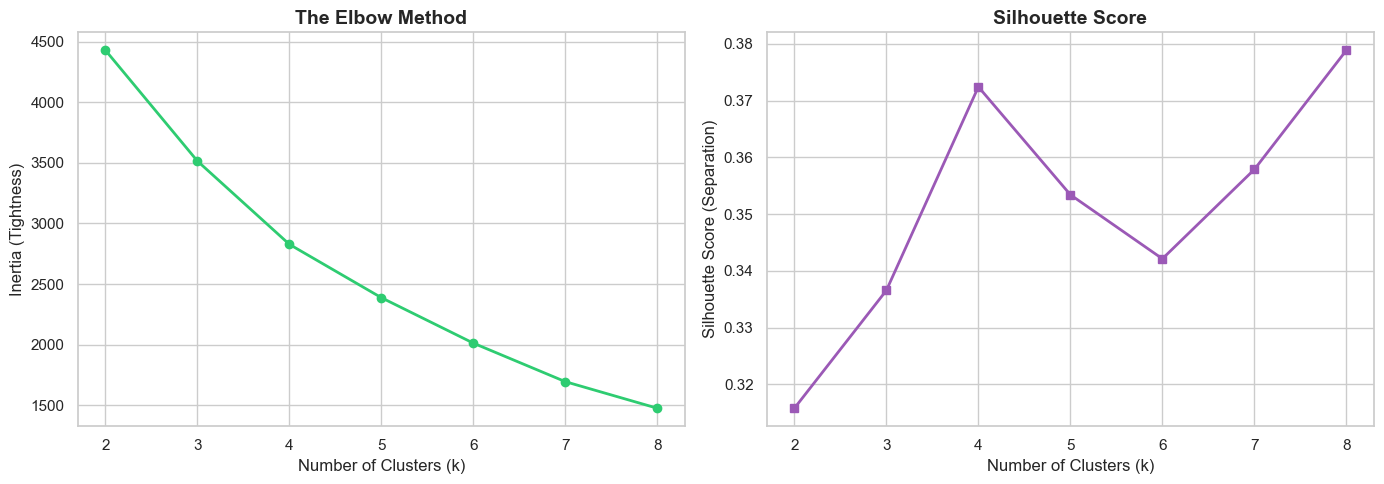

In [8]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

print("--- Finding the Optimal Number of Financial Personas ---")
print("Training 7 different K-Means models (k=2 to k=8). Please wait...")

inertia_values = [] # how tight each clustering
silhouette_scores = [] # how well-separated clusters are
k_range = range(2, 9)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled_df)
    inertia_values.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled_df, kmeans.labels_))

# Plot the results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertia_values, marker='o', color='#2ecc71', linewidth=2)
axes[0].set_title('The Elbow Method', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (Tightness)')

axes[1].plot(k_range, silhouette_scores, marker='s', color='#9b59b6', linewidth=2)
axes[1].set_title('Silhouette Score', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score (Separation)')

plt.tight_layout()
plt.show()

### Selecting the Optimal Number of Personas
Although the Silhouette Score indicates `k=8` produces slightly tighter mathematical groupings, the improvement over `k=5` is marginal. We selected `k=5` because it provides a stronger balance between cluster separation, interpretability, and actionable business segmentation without over-fragmenting the customer base into useless micro-groups.4 clusters was mathematically valid, but 5 offered slightly richer business segmentation while still maintaining acceptable cluster quality.”

In [23]:
print("--- Finalizing and Decoding Elite Financial Personas ---")

# 1. Train final K-Means 
optimal_k = 5
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
ml_df['cluster'] = final_kmeans.fit_predict(X_scaled_df)

# 2. Decode the raw clusters to find out who is who
raw_profiles = ml_df.groupby('cluster').agg({
    'frequency': 'mean',
    'monetary_sum': 'mean',
    'monetary_std': 'mean'
}).reset_index()

# 3. Dynamic Business Persona Mapping
persona_map = {}
for idx, row in raw_profiles.iterrows():
    if row['monetary_sum'] > 100000:
        persona_map[row['cluster']] = "High-Value Loyal"
    elif row['monetary_std'] > 300:
        persona_map[row['cluster']] = "High Variability"
    elif row['monetary_sum'] > 60000 and row['frequency'] > 1000:
        persona_map[row['cluster']] = "Engaged Regulars"
    elif row['frequency'] < 500:
        persona_map[row['cluster']] = "Low Engagement"
    else:
        persona_map[row['cluster']] = "Moderate Casual"

# Apply the dynamic map
ml_df['persona'] = ml_df['cluster'].map(persona_map)

# 4. Final Aggregation
cluster_profiles = ml_df.groupby('persona').agg({
    'active_duration_days': 'mean',  
    'avg_days_between_swipes': 'mean',
    'frequency': 'mean',
    'monetary_sum': 'mean',
    'monetary_max': 'mean',
    'monetary_std': 'mean',
    'future_spend': 'mean', 
    'spend_growth_rate': 'mean',         
    'cc_num': 'count'                
}).rename(columns={'cc_num': 'customer_count'}).round(2)

cluster_profiles = cluster_profiles.sort_values(by='monetary_sum', ascending=False)

print("\nAverage Habits of Each Customer Group (Ranked by Total Historical Spend):")
display(cluster_profiles)

--- Finalizing and Decoding Elite Financial Personas ---

Average Habits of Each Customer Group (Ranked by Total Historical Spend):


,active_duration_days,avg_days_between_swipes,frequency,monetary_sum,monetary_max,monetary_std,future_spend,spend_growth_rate,customer_count
persona,,,,,,,,,
High-Value Loyal,362.88,0.29,1400.25,124708.23,1467.25,108.18,51174.12,0.41,151
High Variability,362.62,0.41,1116.25,81930.57,11774.92,402.87,28891.40,0.35,48
Engaged Regulars,362.93,0.28,1389.22,81009.38,2715.47,122.59,33040.48,0.41,326
Moderate Casual,362.57,0.77,533.45,34406.15,1414.99,104.33,14302.99,0.42,339
Low Engagement,358.61,0.94,409.41,26877.12,1368.40,105.81,10941.08,0.42,44


--- Visualizing the 7-Dimensional Cluster Space via PCA ---
Explained Variance by 2D Projection: 44.6% (PC1) + 25.8% (PC2) = 70.5% Total


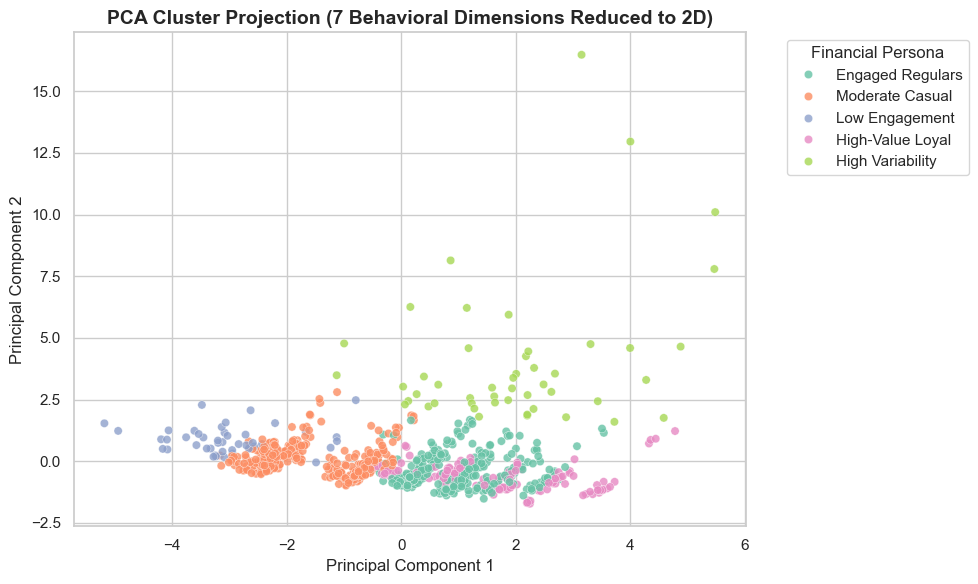

In [24]:
from sklearn.decomposition import PCA

print("--- Visualizing the 7-Dimensional Cluster Space via PCA ---")

# Reduce the 7 scaled features down to 2 Principal Components for 2D viewing
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled_df)

# Elite Polish: Print the Explained Variance
explained_var = pca.explained_variance_ratio_
print(f"Explained Variance by 2D Projection: {explained_var[0]*100:.1f}% (PC1) + {explained_var[1]*100:.1f}% (PC2) = {sum(explained_var)*100:.1f}% Total")

# Add the new coordinates to our dataframe for plotting
ml_df['pca_x'] = principal_components[:, 0]
ml_df['pca_y'] = principal_components[:, 1]

plt.figure(figsize=(10, 6))
# Plot the PCA projection
sns.scatterplot(
    data=ml_df, 
    x='pca_x', 
    y='pca_y', 
    hue='persona', 
    palette='Set2', 
    alpha=0.8, 
    linewidth=0.3
)

plt.title('PCA Cluster Projection (7 Behavioral Dimensions Reduced to 2D)', fontsize=14, fontweight='bold')
# Elite Polish: Mathematically accurate axis labels
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.legend(title='Financial Persona', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Drop the temporary PCA columns so we don't save them into our final dataset
ml_df.drop(columns=['pca_x', 'pca_y'], inplace=True)

In [ ]:
2 PCA dimensions preserve 70.5% of original 7D information

In [25]:
import joblib
import os

print("--- Saving Pipeline for Production ---")

# Save Data
output_path = '../data/processed/ml_features_with_clusters.csv'
ml_df.to_csv(output_path, index=False)
print(f"✅ Clustered dataset saved to: {output_path}")

# Save Models and Metadata
os.makedirs('../models', exist_ok=True)
joblib.dump(final_kmeans, '../models/clv_kmeans_model.joblib')
joblib.dump(scaler, '../models/clv_scaler.joblib')

# ELITE ADDITION: Save the dynamic persona mapping dictionary!
joblib.dump(persona_map, '../models/persona_map.joblib')

print("✅ K-Means Model, StandardScaler, and Persona Map saved successfully.")



--- Saving Pipeline for Production ---
✅ Clustered dataset saved to: ../data/processed/ml_features_with_clusters.csv
✅ K-Means Model, StandardScaler, and Persona Map saved successfully.


## 💼 Behavioral Persona Interpretation & Strategic Recommendations

While the predictive engine (Phase 4) forecasts future spending behavior, the K-Means clustering algorithm provides the foundational customer segmentation. By translating our behavioral variables into professional banking personas, we can deploy grounded, data-driven strategies. *(Note: These are fluid behavioral groupings, not fixed identities; customers may transition between personas over time).*

### 🌟 High-Value Loyal Customers
* **The Profile:** Highest total spend, extreme frequency, and consistent daily usage. 
* **The Strategy:** These represent the bank's most consistently engaged tier. The objective is improving long-term retention and increasing wallet share through premium retention incentives and tier-upgrade opportunities.

### 💳 High Variability Customers
* **The Profile:** Moderate total spend but characterized by massive volatility (`monetary_std`) and significant single-ticket purchases (`monetary_max`).
* **The Strategy:** These customers demonstrate episodic high-ticket spending behavior. Strategy should focus on promotional financing offers and high-ticket merchant partnerships to capture these large transactions.

### 🛒 Stable Everyday Users
* **The Profile:** The largest cohort of users. Characterized by high transaction frequency, moderate total spend, and low volatility.
* **The Strategy:** These customers are the stable backbone of daily transaction volume (groceries, gas). Deploy engagement-based loyalty programs to maintain their consistent usage behavior and keep the card top-of-wallet.

### 📉 Low Engagement Customers
* **The Profile:** Lowest transaction frequency, highest gap between swipes, and lowest total spend. 
* **The Strategy:** These customers demonstrate lower engagement and inconsistent transaction activity. Deploy targeted activation campaigns (e.g., temporary category spend multipliers) to encourage habit-building.